> # ⚠ SUPERSEDED — the GLOBAL baseline cleanup below is REJECTED
>
> This notebook computed a **global** coverage-window cleanup (`λ_clean` = drop 2015–2017 for *all*
> counties). **That conclusion is rejected (2026-06-24):** a global cutoff bakes an *unverifiable
> per-county* assumption ("this county's early years are coverage-suppressed") into the audit anchor —
> wrong for counties whose early years are genuinely high (e.g. Lee FL: 250→120).
>
> **Kept as EVIDENCE**, because it proves the opposite point: the coverage ramp is real *and* the §06 map
> shows counties moving **both up and down** — exactly why one global rule fails. **The home is a
> per-county *statistical adjuster*, not a baseline change.** See
> `docs/dicsscssion/eventization_frequency_contract/07_coverage_ramp_baseline_window.md` and
> `docs/dicsscssion/forward_regime_statistical_router/04_statistical_adjuster_design.md`.
> Read everything below through this correction.

# Baseline Coverage-Window Cleanup — `λ_clean` (Step 1/2)

> ## READ THIS FIRST — what this is, and is NOT
> Today's baseline `λ` is the mean of a county's annual qualifying-event counts over **ALL** observed
> years (2015–2025). A coverage gate showed that full-period mean is biased **~17% LOW** because EAGLE-I
> **under-counted 2015–2017** (sources still onboarding). This notebook computes a **coverage-clean
> baseline `λ_clean`** = the mean over **coverage-stable years only**, and shows — on the annual outage
> series and a national map — *what changes and why*, so an underwriter (and you) can vet it.
>
> - This is a **Step-1/2 BASELINE correction**, **not** a forward factor. The forward bracket
>   (climate + grid) stays untouched.
> - It is **price-RAISING** (the old mean was biased low) → treat as **shadow / for-review**; validate
>   before any live move; confirm composition with the per-customer track.
> - **Calibration lives HERE.** The dashboard will do arithmetic only, on the numbers artifact (§08) —
>   same "swap the numbers" architecture as the location basis.
>
> Decision + evidence: `docs/dicsscssion/eventization_frequency_contract/07_coverage_ramp_baseline_window.md`
> (proposed assumption **A018**, refines **A012**). Origin: the Step-05 router backtest coverage gate.

## §00 — Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT/"curated_outage_data").exists() and ROOT != ROOT.parent: ROOT = ROOT.parent
CATALOG="eagle-i-45min"; TRIGGERS=[2,4,8,12,24]
RAMP_YEARS=[2015,2016,2017]          # the EAGLE-I onboarding-ramp era (under-counted)
CUTOFF=2018                          # default coverage-stable window start (sensitivity shown in §03)
MIN_CLEAN=3                          # need >=3 clean years to trust lambda_clean
TREND=ROOT/f"curated_outage_data/outputs/county_trend/county_yearly_trend__{CATALOG}.parquet"
OUT=ROOT/"notebooks/outputs/baseline_coverage_window"; OUT.mkdir(parents=True, exist_ok=True)
print("ROOT", ROOT, "| cutoff", CUTOFF, "| ramp", RAMP_YEARS)

ROOT /Users/divy/code/work/infrasure_git_codes/outage_pricing | cutoff 2018 | ramp [2015, 2016, 2017]


## §01 — Load annual counts + observed-year mask

In [2]:
tr=pd.read_parquet(TREND); tr["fips"]=tr["fips"].astype(str).str.zfill(5)
def observed(r):
    y=np.asarray(r["years"],int); c=np.asarray(r["yearly_counts"],float); m=np.asarray(r["observed_year_mask"],bool)
    return y[m], c[m]
print(f"{len(tr):,} rows = {tr.fips.nunique()} counties x {tr['T'].nunique()} triggers")

15,450 rows = 3090 counties x 5 triggers


## §02 — THE WHY: EAGLE-I coverage ramped up 2015→2018
Among counties **observed every year** (no composition effect), the typical relative level
(count ÷ that cell's own mean) climbs steeply through 2018 — that is *reporting density* increasing,
not outages doubling. The full-period mean averages those under-counted years in, so it reads low.

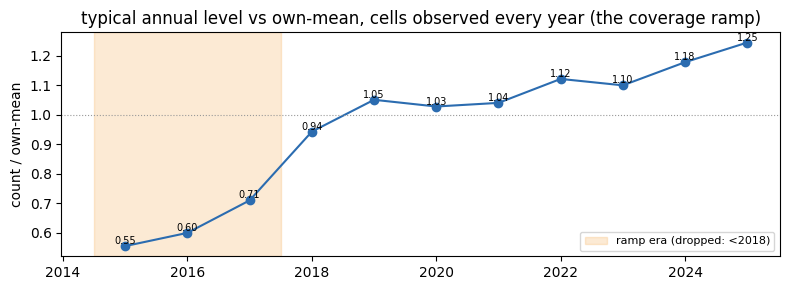

typical level: 2015 0.55 -> 2018 0.94 -> 2025 1.25


In [3]:
rows=[]
for _,r in tr.iterrows():
    y=np.asarray(r["years"],int); c=np.asarray(r["yearly_counts"],float); m=np.asarray(r["observed_year_mask"],bool)
    if not m.all(): continue
    mn=c.mean()
    if mn>0: rows.append({int(yy):cc/mn for yy,cc in zip(y,c)})
F=pd.DataFrame(rows); yrs=sorted(c for c in F.columns)
lvl=[F[y].median() for y in yrs]
fig,ax=plt.subplots(figsize=(8,3))
ax.plot(yrs,lvl,marker="o",color="#2b6cb0")
ax.axhline(1.0,color="#999",lw=.8,ls=":")
ax.axvspan(2014.5,CUTOFF-0.5,color="#f6ad55",alpha=.25,label=f"ramp era (dropped: <{CUTOFF})")
for x,v in zip(yrs,lvl): ax.annotate(f"{v:.2f}",(x,v),fontsize=7,ha="center",va="bottom")
ax.set_title("typical annual level vs own-mean, cells observed every year (the coverage ramp)")
ax.set_ylabel("count / own-mean"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"typical level: 2015 {lvl[0]:.2f} -> 2018 {F[2018].median():.2f} -> 2025 {lvl[-1]:.2f}")

## §03 — Choosing the window (sensitivity)
Where to start the clean window. We default to **2018** (drop the steep 2015–2017 ramp). The table
shows the trade-off: a later cutoff is cleaner but keeps fewer years. The held-out bias check (§07)
confirms dropping the ramp removes most of the low bias.

In [4]:
def lam(c, cutoff=None, years=None):
    if cutoff is not None: c=c[years>=cutoff]
    return c.mean() if len(c) else np.nan
sens=[]
for cut in [2015,2018,2019,2020]:
    bumps=[]; nyr=[]
    for _,r in tr.iterrows():
        y,c=observed(r); full=c.mean()
        cc=c[y>=cut]
        if full>0 and len(cc)>=MIN_CLEAN: bumps.append(cc.mean()/full); nyr.append(len(cc))
    sens.append((cut, np.median(bumps), np.median(nyr)))
print(f"  {'cutoff':>7} {'median λ_clean/λ_full':>22} {'median clean years':>20}")
for cut,b,n in sens: print(f"  {cut:>7} {b:>22.3f} {n:>20.0f}")
print(f"\n  -> default cutoff = {CUTOFF}: drops the 2015-2017 reporting-ramp era, keeps {2025-CUTOFF+1} stable years.")

/var/folders/lx/kqndjxl102vfy6qz_bd4qycc0000gn/T/ipykernel_18087/1936151485.py:8: RuntimeWarning: Mean of empty slice.
  y,c=observed(r); full=c.mean()
/Users/divy/code/personal/renewablesinfo_org/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


   cutoff  median λ_clean/λ_full   median clean years
     2015                  1.000                   11
     2018                  1.120                    8
     2019                  1.144                    7
     2020                  1.150                    6

  -> default cutoff = 2018: drops the 2015-2017 reporting-ramp era, keeps 8 stable years.


## §04 — Compute `λ_clean` vs `λ_full` per (county, trigger)
`λ_full` = mean of all observed years (today). `λ_clean` = mean of observed years ≥ cutoff.
The **bump** = `λ_clean / λ_full`. It is **not** a blanket multiplier — counties that genuinely
declined have bump < 1. Counties with < 3 clean years are flagged, not cleaned.

cells: 15,450 | flagged insufficient_clean: 392

bump (λ_clean/λ_full) at T=8h:  median 1.12  p10 1.00  p90 1.31
  counties that go UP (>1):   80%
  ~unchanged (0.98-1.02):     12%
  go DOWN (<0.98, declined):  8%


/var/folders/lx/kqndjxl102vfy6qz_bd4qycc0000gn/T/ipykernel_18087/1002871851.py:4: RuntimeWarning: Mean of empty slice.
  full=c.mean(); cc=c[y>=CUTOFF]


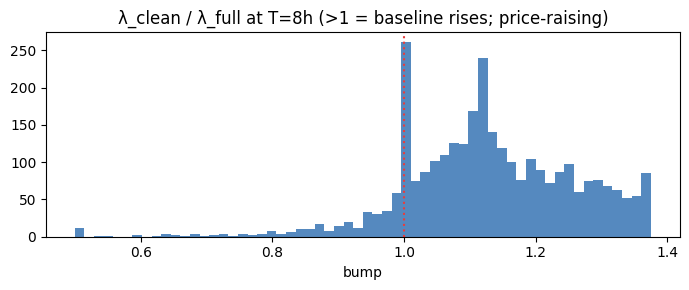

In [5]:
recs=[]
for _,r in tr.iterrows():
    fips,T=r["fips"],int(r["T"]); y,c=observed(r)
    full=c.mean(); cc=c[y>=CUTOFF]
    ok=(full>0 and len(cc)>=MIN_CLEAN)
    recs.append({"fips":fips,"T":T,"lam_full":full,"lam_clean":(cc.mean() if ok else full),
                 "n_clean":len(cc),"n_full":len(c),"flag":("" if ok else "insufficient_clean"),
                 "bump":(cc.mean()/full if ok and full>0 else 1.0)})
B=pd.DataFrame(recs)
print(f"cells: {len(B):,} | flagged insufficient_clean: {(B.flag!='').sum():,}")
b8=B[(B['T']==8)&(B.flag=='')]['bump']
print(f"\nbump (λ_clean/λ_full) at T=8h:  median {b8.median():.2f}  p10 {b8.quantile(.1):.2f}  p90 {b8.quantile(.9):.2f}")
print(f"  counties that go UP (>1):   {(b8>1.02).mean()*100:.0f}%")
print(f"  ~unchanged (0.98-1.02):     {((b8>=.98)&(b8<=1.02)).mean()*100:.0f}%")
print(f"  go DOWN (<0.98, declined):  {(b8<.98).mean()*100:.0f}%")
fig,ax=plt.subplots(figsize=(7,3))
ax.hist(b8.clip(0.5,2.5),bins=60,color="#2b6cb0",alpha=.8); ax.axvline(1.0,color="#e53e3e",ls=":")
ax.set_title("λ_clean / λ_full at T=8h (>1 = baseline rises; price-raising)"); ax.set_xlabel("bump"); plt.tight_layout(); plt.show()

## §05 — WHAT IT MEANS: the annual outage series, before vs after (per-county)
For a few representative counties: the annual qualifying-event series, the dropped ramp era shaded,
and the two baselines — `λ_full` (today, dashed) vs `λ_clean` (solid). This is what the underwriter sees.

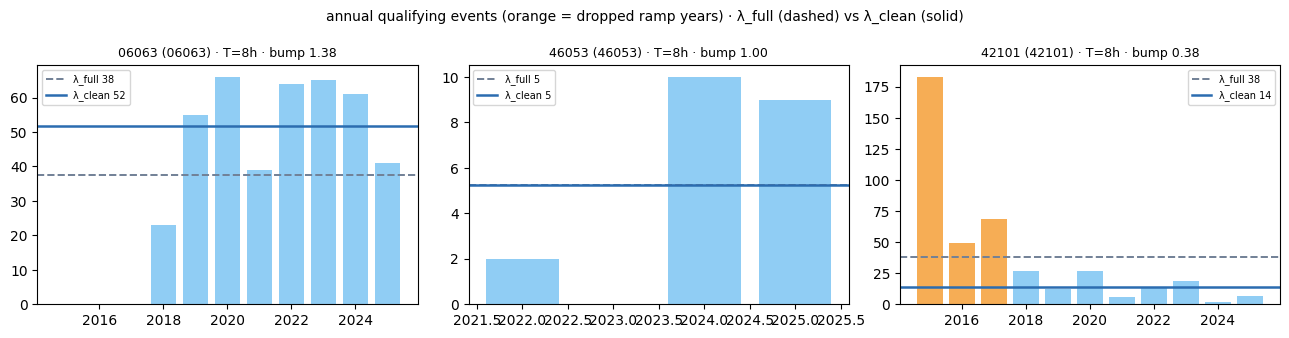

In [6]:
# county name lookup (best-effort)
name={}
try:
    import json; cbs=json.load(open(ROOT/"web/lib/data/counties-by-state.json"))
    def walk(o):
        if isinstance(o,dict):
            if "fips" in o and ("name" in o or "county" in o): name[str(o["fips"]).zfill(5)]=o.get("name") or o.get("county")
            for v in o.values(): walk(v)
        elif isinstance(o,list):
            for v in o: walk(v)
    walk(cbs)
except Exception as e: print("(name lookup skipped:", repr(e)[:80], ")")
def lbl(f): return f"{name.get(f,f)} ({f})"
# pick exemplars at T=8h: biggest rise, ~unchanged, a decline
cand=B[(B['T']==8)&(B.flag=='')&(B.lam_full>=5)].copy()
ex=[cand.sort_values('bump').iloc[-1]['fips'],                                   # biggest rise
    cand.iloc[(cand.bump-1.0).abs().argsort()].iloc[0]['fips'],                  # ~unchanged
    cand.sort_values('bump').iloc[0]['fips']]                                    # biggest decline
fig,axes=plt.subplots(1,3,figsize=(13,3.4))
for ax,f in zip(axes,ex):
    r=tr[(tr.fips==f)&(tr['T']==8)].iloc[0]; y,c=observed(r)
    row=B[(B.fips==f)&(B['T']==8)].iloc[0]
    ax.bar(y,c,color=["#f6ad55" if yy in RAMP_YEARS else "#90cdf4" for yy in y])
    ax.axhline(row.lam_full,color="#718096",ls="--",lw=1.4,label=f"λ_full {row.lam_full:.0f}")
    ax.axhline(row.lam_clean,color="#2b6cb0",ls="-",lw=1.8,label=f"λ_clean {row.lam_clean:.0f}")
    ax.set_title(f"{lbl(f)} · T=8h · bump {row.bump:.2f}",fontsize=9); ax.legend(fontsize=7)
fig.suptitle("annual qualifying events (orange = dropped ramp years) · λ_full (dashed) vs λ_clean (solid)",fontsize=10)
plt.tight_layout(); plt.show()

## §06 — WHERE IT MATTERS: national map of the baseline move
County choropleth of the bump `λ_clean/λ_full` at T=8h (CONUS). Counties that onboarded late / were
under-counted early get the biggest uplift; counties that genuinely declined move down. Diverging
scale centered at 1.0.

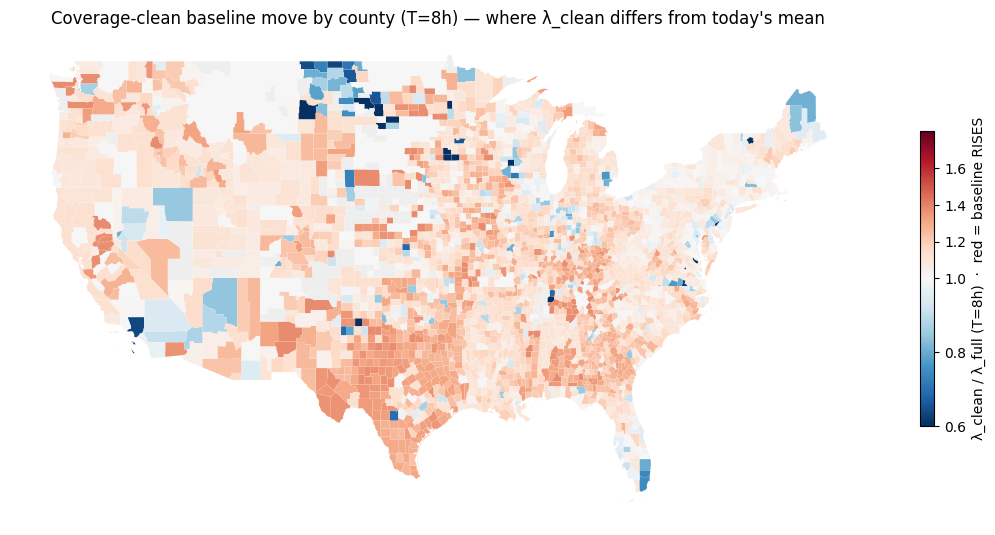

states with the largest median baseline uplift at T=8h (FIPS state code):
st
48    1.29
21    1.24
13    1.23
28    1.19
29    1.18
40    1.16
19    1.16
39    1.15


In [7]:
import geopandas as gpd
from matplotlib.colors import TwoSlopeNorm
GJ=OUT/"geojson-counties-fips.json"
if not GJ.exists():
    import urllib.request; urllib.request.urlretrieve("https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json", GJ)
g=gpd.read_file(GJ); g["fips"]=g["id"].astype(str).str.zfill(5)
g=g[~g["fips"].str[:2].isin(["02","15"])]; g=g[g["fips"].str[:2].astype(int)<60]   # CONUS
m=g.merge(B[(B['T']==8)&(B.flag=='')][["fips","bump"]],on="fips",how="left")
fig,ax=plt.subplots(figsize=(11,6.2))
m.plot(column="bump",cmap="RdBu_r",norm=TwoSlopeNorm(vmin=0.6,vcenter=1.0,vmax=1.8),
       linewidth=0.05,edgecolor="#fff",ax=ax,legend=True,missing_kwds={"color":"#eee"},
       legend_kwds={"label":"λ_clean / λ_full (T=8h)  ·  red = baseline RISES","shrink":0.5})
ax.set_title("Coverage-clean baseline move by county (T=8h) — where λ_clean differs from today's mean")
ax.axis("off"); plt.tight_layout(); plt.show()
# state summary (robust, no-geometry view)
B2=B[(B['T']==8)&(B.flag=='')].copy(); B2["st"]=B2.fips.str[:2]
st=B2.groupby("st")["bump"].median().sort_values(ascending=False)
print("states with the largest median baseline uplift at T=8h (FIPS state code):")
print(st.head(8).round(2).to_string())

## §07 — VALIDATION: does `λ_clean` predict recent years with less bias?
If the cleanup is right, the clean-window mean should UNDER-predict the held-out recent years much less
than the full-period mean (which is dragged down by the under-counted ramp).

In [8]:
def bias_of(use_clean):
    err=tot=0.0
    for _,r in tr.iterrows():
        y,c=observed(r)
        for ty in (2024,2025):
            if ty not in y: continue
            tr_y=y[y<ty]; tr_c=c[y<ty]
            if use_clean: tr_c=tr_c[tr_y>=CUTOFF]
            if len(tr_c)<3: continue
            pred=tr_c.mean(); obs=c[y==ty][0]; err+=pred-obs; tot+=obs
    return err/tot
bf,bc=bias_of(False),bias_of(True)
print(f"predicting 2024-2025 held out:")
print(f"  λ_full  (all years)      bias {bf:+.3f}   <- today's baseline, under-predicts")
print(f"  λ_clean (>= {CUTOFF})        bias {bc:+.3f}   <- coverage-clean, much less biased")
print(f"  => the clean window removes ~{(1-abs(bc)/abs(bf))*100:.0f}% of the systematic low bias.")

predicting 2024-2025 held out:
  λ_full  (all years)      bias -0.165   <- today's baseline, under-predicts
  λ_clean (>= 2018)        bias -0.077   <- coverage-clean, much less biased
  => the clean window removes ~54% of the systematic low bias.


## §08 — Emit the numbers artifact (shadow; dashboard reads this)

In [9]:
art=B[["fips","T","lam_full","lam_clean","bump","n_clean","n_full","flag"]].copy()
art.to_parquet(OUT/"lambda_clean.parquet")
art.to_csv(OUT/"lambda_clean.csv",index=False)
card=f'''# Baseline coverage-window cleanup — model card ({CATALOG})
- lambda_clean = mean of annual qualifying counts over coverage-stable years (>= {CUTOFF}); lambda_full = today's all-year mean.
- cells: {len(B)} | insufficient_clean (kept = lambda_full): {(B.flag!="").sum()}
- T=8h bump (clean/full): median {B[(B["T"]==8)&(B.flag=="")].bump.median():.2f}; price-RAISING where >1.
- held-out 2024-25 bias: lambda_full {bf:+.2f} -> lambda_clean {bc:+.2f}.
- status: SHADOW / for-review. Step-1/2 baseline correction (A018 proposed, refines A012). NOT a forward factor.
- caveats: price-raising; validate before live; confirm per-customer composition; window cutoff {CUTOFF} (see sensitivity).'''
(OUT/"model_card.md").write_text(card)
(OUT/"assumptions_to_register.md").write_text("A018 (proposed) — Baseline lambda uses a coverage-stable window (drop EAGLE-I onboarding-ramp years <"+str(CUTOFF)+"); refines A012; price-raising; shadow-validated before live.")
print("wrote:", *[p.name for p in sorted(OUT.glob("*")) if p.suffix in (".parquet",".csv",".md")])

wrote: assumptions_to_register.md lambda_clean.csv lambda_clean.parquet model_card.md


## §09 — Verdict

In [10]:
print(f'''VERDICT
- Today's baseline (full-period mean) is biased ~{abs(bf)*100:.0f}% LOW, mostly because EAGLE-I under-counted
  2015-2017. lambda_clean (mean over >= {CUTOFF}) cuts that to ~{abs(bc)*100:.0f}% and is the honest baseline.
- It is price-RAISING for early-onboarding counties (T=8h median bump {B[(B["T"]==8)&(B.flag=="")].bump.median():.2f}),
  heterogeneous (some counties decline), and a Step-1/2 correction -- NOT a forward factor.
- Ships as a SHADOW numbers artifact (lambda_clean.parquet); dashboard shows lambda_clean beside today's lambda
  in the BASELINE section, with this why-curve + per-county before/after + the map. Forward bracket untouched.
- Open: global cutoff {CUTOFF} vs per-county onboarding-aware start; shared window with the experience band.''')

VERDICT
- Today's baseline (full-period mean) is biased ~17% LOW, mostly because EAGLE-I under-counted
  2015-2017. lambda_clean (mean over >= 2018) cuts that to ~8% and is the honest baseline.
- It is price-RAISING for early-onboarding counties (T=8h median bump 1.12),
  heterogeneous (some counties decline), and a Step-1/2 correction -- NOT a forward factor.
- Ships as a SHADOW numbers artifact (lambda_clean.parquet); dashboard shows lambda_clean beside today's lambda
  in the BASELINE section, with this why-curve + per-county before/after + the map. Forward bracket untouched.
- Open: global cutoff 2018 vs per-county onboarding-aware start; shared window with the experience band.
